# Pipeline PySpark local — Fruits!

**Objectif** : reproduire et comprendre la chaîne de traitement développée par l'alternant (voir `P8_Mode_opératoire/`), puis la compléter avec une étape de réduction de dimension par PCA en PySpark.

> Travail sur un échantillon de taille adapté au travail en local (`data/sample`, 10 classes x 30 images, généré par `scripts/prepare_sample.py`) avant tout passage à l'échelle sur AWS EMR.


# 1. Chargement des données

## Imports

In [1]:
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, element_at, split

### Notes - Sparks

**A. But et Fonctionnement de Spark**
Spark est un moteur de calcul distribué. Une "application Spark" est composée de 4 types d'acteurs/processus :

- *un driver program* qui est le processus qui pilote l'exécution, construit le plan de calcul et coordonne les tâches (*tasks*) ;
- un *cluster manager* qui sert d'intermédiaire entre le *driver program* et les machines physqiues (en local, ce rôle est implicite ; sur AWS-EMR, ce sera YARN)  ;
- *des workers node*  qui sont les machines ud clusteret qui mettent à dispositions les ressources nécessaires à l'exécution 
- *des executors* qui exécutent réellement le travail, les *tasks* sur les partitions de données .

**B. Définition des termes**
- *Driver program* : le processus qui exécute la fonction principale de votre application et crée le SparkContext.
- *Cluster manager* : le service externe qui négocie et alloue les ressources du cluster au driver (Standalone manager, YARN, Mesos, Kubernetes..) ; le driver ne parle jamais directement aux worker nodes, il passe par le cluster manager pour obtenir les ressources.
- *Worker node* : une machine du cluster qui a des ressources disponibles (CPU, mémoire) pour exécuter les tasks. 
- *Executor* : un processus (une JVM) lancé sur un worker node, dédié à une application Spark précise. C'est lui qui exécute réellement les tâches et garde les données en cache.
- *Task* : une unité de travail envoyée à un executor — concrètement, l'application d'une opération sur une seule partition de données. Un executor exécute généralement plusieurs tasks, souvent une par cœur/thread dont il dispose.

*Source : https://spark.apache.org/docs/latest/cluster-overview.html*

**C. Mode local**

**Ici, nous codons et exécutons la partie ***driver program*** : nous décrivons le calcul à Spark qui se charge de le distribuer.**

- En mode local[*], il n'y a pas de vrais processus séparés. Driver et executor tournent dans la même JVM, l'unique processus Python/Java lancé quand on exécutera la cellule SparkSession.builder...getOrCreate(). 
- Le parallélisme ne vient pas de plusieurs machines ou processus, mais de ***threads*** à l'intérieur de ce processus unique 
> local[*] demande à Spark d'utiliser autant de threads que de cœurs disponibles sur note machine. C'est une simulation de cluster.

**D. Sur AWS EMR**


Il s'agit d'un réel cluster de machines distinctes, dont le ***découpage*** est le suivant :

- Le *nœud primaire* (une instance EC2 dédiée) héberge le driver, ainsi que le gestionnaire de ressources YARN (le système qui décide où placer le travail sur le cluster) ; EMR utilise YARN comme gestionnaire de cluster par défaut.
- Les **nœuds core et task* (d'autres instances EC2) hébergent quant à eux les *executors*, chacun tournant dans un *conteneur YARN* (une tranche isolée de CPU/mémoire allouée par YARN sur cette machine). Une même machine peut héberger plusieurs conteneurs/executors selon les ressources disponibles et la configuration.

> La différence entre nœuds core et task : les *nœuds core* stockent aussi des données (HDFS), les *nœuds task* ne font qu'exécuter le calcul, ce qui les rend éligibles aux *instances spot* (moins chères) puisqu'ils ne conservent pas de données permanentes.

> le code Python développé ici ne change donc pas entre le mode local ou le mode cloud, seul .master(..) diffère. Cependant les processus machines en arrière-plan sont différents : threads dans un seul processus en local, contre plusieurs machines et processus JVM séparés sur EMR.

**E. La SparkSession**

***La SparkSession n'est pas un acteur en soi***, ni le cluster manager, ni un worker node, ni un executor. **C'est l'interface du driver program**, l'objet python qu'on manipule pour piloter tout le reste.


Concrètement, quand nous exécutons :

> spark = SparkSession.builder.appName("P11_Fruits").master("local[*]").getOrCreate()

on initialise le driver program. Sur un vrai cluster, cela déclencherait le contact avec le *cluster manager* pour négocier des ressources et obtenir des *executors*. En local, cette ligne met en place le pool de *threads* simulant le cluster.


**SparkSession unifie et encapsule plusieurs objets en un seul point d'entrée :**
- un ***SparkContext*** pour parler au cluster manager et manipuler les RDD (la structure de données bas niveau de Spark);
- un ***SQLContext*** pour les DataFrames et le SQL, 
- un ***HiveContext*** (maintenant obsolète) qui permettait à Spark de lire et d'écrire des tables Hive et d'exécuter des requêtes en HiveQL, pour l'intégration Hive, un système d'entrepôt de données permettant d'interroger de gros volumes de fichiers distribués avec un langage proche du SQL (HiveQL).


> sc = spark.sparkContext permet donc de récupérer cet objet bas niveau, toujours accessible depuis la session, car certaines opérations d'historiques comme sc.broadcast(..), sont définies sur le SparkContext, pas directement sur SparkSession.

**Synthèse** 

***La SparkSession est l'orchestrateur du driver program***, le seul objet dont on a besoin dans votre code pour déclencher tout ce qui se passe ensuite avec le cluster manager, les worker nodes et les executors, sans jamais avoir à les manipuler nous-même.



In [ ]:
# pour la portabilité du code en mode local, recherhce dans le répertoire courant et ses parents jusqu'à trouver le fichier `requirements.txt`
# inutile pour le script cloud, car on définira le path par une variable 

def find_project_root(marker: str = "requirements.txt") -> str:
    """Walk up from the current working directory until `marker` is found."""
    current_dir = os.getcwd()
    while not os.path.exists(os.path.join(current_dir, marker)):
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not locate project root (marker: {marker})")
        current_dir = parent_dir
    return current_dir


PROJECT_ROOT = find_project_root()
PATH_DATA = os.path.join(PROJECT_ROOT, "data", "sample")
PATH_RESULT = os.path.join(PROJECT_ROOT, "results")

print(f"PATH_DATA:   {PATH_DATA}")
print(f"PATH_RESULT: {PATH_RESULT}")

PATH_DATA:   /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample
PATH_RESULT: /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/results


In [ ]:
# création de la sparksession
spark = (
    SparkSession.builder
    .appName("P11_Fruits") # nom visible dans le spark UI et les logs EMR
    .master("local[*]") # définition du mode d'éxéctuion,  en local avec tous les cœurs disponibles, différent pour l'EMR
    .config("spark.sql.parquet.writeLegacyFormat", "true")
    .getOrCreate()
)
sc = spark.sparkContext

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/25 15:24:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Chargement des images au format binaire

`spark.read.format("binaryFile")` charge chaque image comme une ligne contenant ses métadonnées (chemin, date de modification,  taille et contenu brut en bytes) pas de décodage à ce stade. C'est volontaire : on garde le prétraitement (redimensionnement, normalisation) pour l'étape de featurisation, où il sera appliqué en parallèle sur chaque partition.

`recursiveFileLookup` parcourt tous les sous-dossiers de `data/sample` (un sous-dossier par classe), et `pathGlobFilter` ne garde que les `.jpg`.

In [3]:
images = (
    spark.read.format("binaryFile")
    .option("pathGlobFilter", "*.jpg")
    .option("recursiveFileLookup", "true")
    .load(PATH_DATA)
)

images.printSchema()
images.select("path", "length").show(5, truncate=False)

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)




[Stage 0:>                                                          (0 + 1) / 1]



+-----------------------------------------------------------------------------------------------------------------------------------------+------+
|path                                                                                                                                     |length|
+-----------------------------------------------------------------------------------------------------------------------------------------+------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/10_100.jpg|6168  |
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/14_100.jpg|6151  |
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/11_100.jpg|6145  |
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawbe

## Extraction du label

Il n'y a pas de colonne "label" dans les données brutes : la classe de chaque image est encodée dans son chemin (`.../data/sample/Apricot/0_100.jpg` → label `Apricot`). `split(path, '/')` découpe le chemin en une liste de segments, `element_at(..., -2)` prend l'avant-dernier — c'est-à-dire le nom du dossier parent de l'image.

In [4]:
images = images.withColumn("label", element_at(split(col("path"), "/"), -2))

images.select("path", "label").show(5, truncate=False)
images.groupBy("label").count().show()

+-----------------------------------------------------------------------------------------------------------------------------------------+----------------+
|path                                                                                                                                     |label           |
+-----------------------------------------------------------------------------------------------------------------------------------------+----------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/10_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/14_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/11_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MA

+----------------+-----+
|           label|count|
+----------------+-----+
|Strawberry Wedge|   30|
|           Guava|   30|
|          Papaya|   30|
|           Dates|   30|
|  Apple Braeburn|   30|
|       Mango Red|   30|
|         Apricot|   30|
|        Cherry 1|   30|
|   Pear Williams|   30|
|          Plum 3|   30|
+----------------+-----+



# 2. Préparation du modèle (transfer learning)

## Imports

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2


### Pourquoi le transfer learning, et pourquoi MobileNetV2 ?

On ne nous demande pas d'entraîner un modèle de classification pour l'instant — seulement de préparer la chaîne de traitement (preprocessing + réduction de dimension) qui servira plus tard à un moteur de classification. On a donc besoin, pour chaque image, d'un **vecteur de caractéristiques** (une empreinte numérique résumant son contenu visuel), pas d'une prédiction de classe.

Le transfer learning permet d'obtenir ce vecteur sans rien entraîner : on réutilise un réseau déjà entraîné (ici **MobileNetV2**, entraîné sur ImageNet), et on récupère la sortie de son **avant-dernière couche** plutôt que sa couche finale. La dernière couche de MobileNetV2 est une couche `softmax` à 1000 classes (les catégories d'ImageNet) — inutile ici. La couche juste avant contient un vecteur dense de 1280 valeurs qui encode les caractéristiques visuelles de l'image, indépendamment de toute classification.

MobileNetV2 est choisi pour deux raisons pratiques : c'est un modèle léger et rapide (conçu à l'origine pour tourner sur mobile), et son vecteur de sortie (1280 dimensions) est déjà relativement compact comparé à d'autres architectures, un bon point de départ avant la PCA de la section 4.

In [ ]:

base_model = MobileNetV2(
    weights="imagenet",
    include_top=True,
    input_shape=(224, 224, 3),
)

feature_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
feature_model.summary()

2026-07-08 19:32:44.379623: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



       0/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


   49152/14536120 ━━━━━━━━━━━━━━━━━━━━ 31s 2us/step


   81920/14536120 ━━━━━━━━━━━━━━━━━━━━ 34s 2us/step


  147456/14536120 ━━━━━━━━━━━━━━━━━━━━ 25s 2us/step

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### Pourquoi diffuser (broadcast) les poids plutôt que le modèle lui-même ?

On retrouve ici le même principe driver/workers que pour les images, appliqué cette fois au modèle. `feature_model` est un objet Python complexe (graphe de calcul TensorFlow) : il n'est pas conçu pour être sérialisé et envoyé tel quel à chaque worker à chaque tâche — ça échouerait ou serait très inefficace.

La solution : chaque worker **reconstruit lui-même l'architecture** du modèle (quelques lignes de code, peu coûteux), puis se voit attribuer les **poids déjà entraînés** via un mécanisme de diffusion (broadcast) de Spark. Le broadcast copie une donnée une seule fois vers chaque machine du cluster (pas une fois par tâche), où elle reste en cache — bien plus efficace que de la retransmettre à chaque appel.

C'est exactement l'étape que le brief du Projet 11 met en avant : diffuser les poids du modèle sur les clusters plutôt que de les recharger à chaque tâche.

In [6]:
broadcast_weights = sc.broadcast(feature_model.get_weights())


def model_fn():
    """Rebuild the MobileNetV2 feature-extraction model and load the broadcasted weights.

    Called once per worker (not once per image), so the model is reconstructed
    only a handful of times regardless of how many images are processed.
    """
    base = MobileNetV2(weights="imagenet", include_top=True, input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    model = Model(inputs=base.input, outputs=base.layers[-2].output)
    model.set_weights(broadcast_weights.value)
    return model

## 3. Featurisation via pandas UDF

### Pourquoi une pandas UDF, et pourquoi "Scalar Iterator" ?

Une UDF (*User Defined Function*) Spark classique appelle votre fonction Python **ligne par ligne** — ce qui est très lent, car chaque appel implique un aller-retour entre la JVM (Spark) et le processus Python. Une **pandas UDF** fonctionne différemment : Spark lui envoie des **lots** de lignes sous forme de `pandas.Series` (via Arrow, un format d'échange mémoire optimisé), la fonction traite le lot en une fois, et renvoie le résultat en bloc — beaucoup plus efficace, en particulier pour appeler un modèle de deep learning qui est lui-même optimisé pour traiter des batches d'images plutôt qu'une image isolée.

La variante **Scalar Iterator** (`PandasUDFType.SCALAR_ITER`) va un cran plus loin : au lieu de recevoir un seul lot, la fonction reçoit un **itérateur de lots**. Cela permet d'appeler `model_fn()` **une seule fois par worker**, avant de traiter tous les lots qui lui sont confiés, plutôt que de reconstruire le modèle à chaque lot — un gain important quand on traite des milliers d'images.

La pile d'appels est la suivante :
- `featurize_udf` (pandas UDF Scalar Iterator) — charge le modèle une fois
  - `featurize_series` — featurise un lot d'images (`pd.Series`)
    - `preprocess` — décode et prétraite une image individuelle

In [7]:
import io

import numpy as np
import pandas as pd
from PIL import Image
from pyspark.sql.functions import PandasUDFType, pandas_udf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array


def preprocess(content: bytes) -> np.ndarray:
    """Decode raw JPEG bytes and prepare a single image for MobileNetV2."""
    img = Image.open(io.BytesIO(content)).resize([224, 224])
    arr = img_to_array(img)
    return preprocess_input(arr)


def featurize_series(model: Model, content_series: pd.Series) -> pd.Series:
    """Featurize a batch of raw images using the given model."""
    input_batch = np.stack(content_series.map(preprocess))
    preds = model.predict(input_batch)
    output = [p.flatten() for p in preds]
    return pd.Series(output)


@pandas_udf("array<float>", PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter):
    """Scalar Iterator pandas UDF: loads the model once, then reuses it across batches."""
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

/opt/anaconda3/envs/env_p11_chantepie/lib/python3.10/site-packages/pyspark/sql/pandas/functions.py:761: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


### Exécution

`repartition(n)` redécoupe explicitement le DataFrame en `n` partitions avant la featurisation, pour s'assurer que le travail est bien réparti entre les workers disponibles (par défaut, le nombre de partitions dépend du nombre de fichiers/blocs sources, pas forcément optimal). Sur notre échantillon de 300 images, on reste volontairement modeste.

**Pourquoi `.persist()` ?** Spark est *lazy* : sans cette ligne, chaque action ultérieure sur `features_df` (la PCA, l'écriture finale, etc.) redéclencherait tout le calcul depuis le début — y compris la featurisation par MobileNetV2, l'étape la plus coûteuse du pipeline. `.persist()` demande à Spark de garder le résultat en mémoire (ou sur disque si besoin) après le premier calcul, pour le réutiliser tel quel dans les étapes suivantes.

In [8]:
features_df = images.repartition(8).select(
    col("path"),
    col("label"),
    featurize_udf("content").alias("features"),
)

features_df.persist()
print(f"Nombre d'images featurisées : {features_df.count()}")
features_df.select("path", "label").show(5, truncate=False)

2026-07-08 19:34:13.308179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-08 19:34:13.312484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-08 19:34:13.313565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-08 19:34:13.320066: I tensorflow/core/platform/cpu_featu


1/2 ━━━━━━━━━━━━━━━━━━━━ 13s 14s/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step  


2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step



2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step


Nombre d'images featurisées : 300


+------------------------------------------------------------------------------------------------------------------------------------------+----------------+
|path                                                                                                                                      |label           |
+------------------------------------------------------------------------------------------------------------------------------------------+----------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/162_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/172_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/157_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURS

## 4. Réduction de dimension (PCA PySpark)

### Pourquoi une PCA, et pourquoi en PySpark plutôt qu'avec scikit-learn ?

Le vecteur de sortie de MobileNetV2 a 1280 dimensions. C'est déjà beaucoup plus compact qu'une image brute, mais ça reste volumineux à grande échelle : sur les 22 000+ images du dossier `Test` de l'alternant (et bien plus après la mise à l'échelle), stocker et manipuler des vecteurs à 1280 dimensions par image a un coût de stockage et de calcul non négligeable pour les traitements en aval (le futur moteur de classification). La PCA (*Principal Component Analysis*) réduit cette dimensionnalité en ne gardant que les axes qui expliquent le plus de variance dans les données, en perdant le moins d'information possible.

**Pourquoi pas `sklearn.decomposition.PCA` ?** Parce que l'implémentation scikit-learn s'attend à recevoir l'intégralité de la matrice de données **en mémoire, sur une seule machine**. Ça fonctionne pour 300 images, mais devient impossible sur des millions d'images — on retomberait exactement dans le piège qu'on a déjà rencontré avec `PIL` : reconstituer un goulot d'étranglement séquentiel là où Spark est censé distribuer le travail.

`pyspark.ml.feature.PCA` est conçu différemment, et le mécanisme est instructif — on retrouve encore le principe driver/workers :
1. Chaque worker calcule, sur sa partition, une contribution à la **matrice de covariance** (une matrice `1280 × 1280`, dont la taille ne dépend donc pas du nombre d'images).
2. Ces contributions sont agrégées (opération distribuée) pour obtenir la matrice de covariance complète.
3. Cette matrice, petite et fixe en taille, est ensuite décomposée (calcul des vecteurs propres) **une seule fois sur le driver** — un calcul local mais peu coûteux, car il ne dépend que du nombre de dimensions (1280), jamais du nombre de lignes.
4. Chaque ligne du jeu de données est ensuite projetée sur ces nouveaux axes — une opération à nouveau distribuée, appliquée en parallèle par les workers.

Le calcul lourd (parcourir toutes les images) est distribué ; le calcul fin (décomposition) reste centralisé mais reste petit quel que soit le volume de données. C'est ce qui permet à la PCA de "passer à l'échelle" avec le volume de données annoncé par Paul.

### Préparation : du tableau au vecteur, et centrage-réduction

Deux étapes préalables, obligatoires avant d'appliquer la PCA de `pyspark.ml` :

1. **Conversion de type** : `featurize_udf` renvoie une colonne `array<float>` (un simple tableau), mais les algorithmes de `pyspark.ml` attendent un type `Vector` (le type dédié à l'algèbre linéaire dans MLlib). `array_to_vector` fait cette conversion.
2. **Centrage-réduction (`StandardScaler`)** : la PCA cherche les axes de variance maximale — si on ne centre pas les données, le premier axe trouvé aura tendance à capturer surtout la moyenne des données plutôt que leur variabilité réelle, ce qui fausse le résultat. C'est une étape standard, systématiquement recommandée avant toute PCA.

In [9]:
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.functions import array_to_vector

vector_df = features_df.select(
    "path",
    "label",
    array_to_vector("features").alias("features_vec"),
)

scaler = StandardScaler(
    inputCol="features_vec",
    outputCol="scaled_features",
    withMean=True,
    withStd=True,
)
scaler_model = scaler.fit(vector_df)
scaled_df = scaler_model.transform(vector_df)

scaled_df.select("path", "label", "scaled_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|                                                                            path|           label|                                                                 scaled_features|
+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[0.03407200743297145,-0.7058729283341508,-0.3849294075632169,-0.3859354047247...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-0.4071324345362666,-0.47160315487568183,-0.3849294075632169,-0.385935404724...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry We

### Choix du nombre de composantes (k)

Il n'y a pas de "bon k" universel : c'est un compromis entre compression et perte d'information, à arbitrer en regardant la **variance expliquée cumulée**. On ajuste ici une PCA avec un `k` volontairement large (`k=100`, sur seulement 300 images et 10 classes) pour observer la courbe de variance expliquée, puis on choisira un `k` plus petit en fonction de ce qu'elle montre — plutôt que de fixer un chiffre arbitraire a priori.

**Point de vigilance pour la suite du projet** : ce choix de `k` est fait ici sur un échantillon de 10 classes non représentatif du jeu de données complet (131 classes). Il faudra le revalider sur le jeu de données complet une fois sur EMR — la variance expliquée par un même `k` peut différer significativement selon la diversité des images.

26/07/08 19:35:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


26/07/08 19:35:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


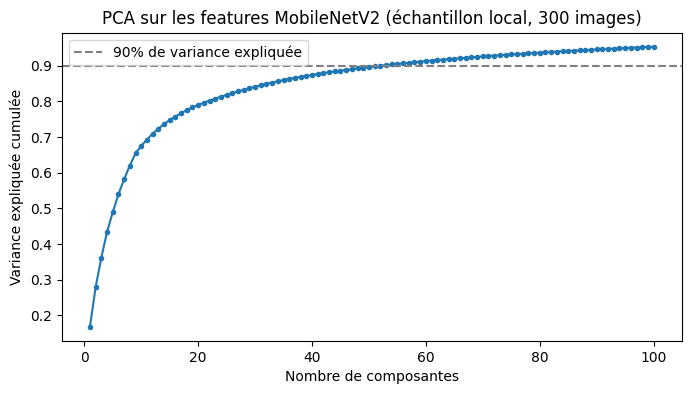

In [10]:
pca_explore = PCA(k=100, inputCol="scaled_features", outputCol="pca_features_full")
pca_explore_model = pca_explore.fit(scaled_df)

explained_variance = pca_explore_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=3)
plt.axhline(0.90, color="gray", linestyle="--", label="90% de variance expliquée")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("PCA sur les features MobileNetV2 (échantillon local, 300 images)")
plt.legend()
plt.show()

In [11]:
k_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
print(f"Composantes nécessaires pour 90% de variance expliquée : {k_90}")
print(f"Variance expliquée avec {k_90} composantes : {cumulative_variance[k_90 - 1]:.4f}")

Composantes nécessaires pour 90% de variance expliquée : 53
Variance expliquée avec 53 composantes : 0.9012


On réajuste maintenant la PCA avec ce `k`, pour obtenir le DataFrame final réduit.

In [12]:
pca = PCA(k=k_90, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
pca_df = pca_model.transform(scaled_df)

pca_df.select("path", "label", "pca_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|                                                                            path|           label|                                                                    pca_features|
+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-5.287437330475509,0.9938178276457581,20.97620808692644,6.498999952806434,-3...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-2.5941090307530086,0.32458644373422624,19.85911016635906,7.739687193770584,...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry We

## 5. Sauvegarde et validation des résultats

### Sauvegarde

**Choix du format : parquet, pas CSV**

Le seul texte qui mentionne un format, dans les livrables officiels du projet, est : *"une matrice écrite sur un fichier CSV ou autre"*. CSV n'est donc donné qu'à titre d'exemple, pas imposé — ni le référentiel d'évaluation ni les contraintes techniques ne restreignent davantage ce choix.

Parquet est conservé plutôt que CSV pour plusieurs raisons :
- c'est le **format natif de Spark** : il gère nativement les colonnes de type `Vector`/`array` (comme `pca_features`), alors que le CSV est purement tabulaire et aurait exigé d'aplatir le vecteur en autant de colonnes que de composantes (`pca_0`, `pca_1`, ..., `pca_52`) ;
- il est **auto-descriptif** (schéma et types conservés à l'écriture), ce qui évite les erreurs de parsing à la relecture ;
- il prolonge la démarche de l'alternant, qui écrivait déjà en parquet.

Le compromis accepté : un fichier parquet nécessite `pandas` + `pyarrow` (ou un outil compatible) pour être ouvert, contrairement à un CSV lisible dans n'importe quel tableur — point à garder en tête si l'évaluateur souhaite inspecter le fichier directement pendant la soutenance.

`vector_to_array` reconvertit la colonne `Vector` (type MLlib) en simple tableau avant écriture : plus portable pour la lecture ultérieure hors Spark (ici avec `pandas.read_parquet`), qui ne connaît pas nativement le type `Vector`.

On ne garde que `path`, `label` et `pca_features` — inutile de conserver le vecteur à 1280 dimensions non réduit dans le résultat final.

In [13]:
from pyspark.ml.functions import vector_to_array

result_df = pca_df.select(
    "path",
    "label",
    vector_to_array("pca_features").alias("pca_features"),
)

result_df.write.mode("overwrite").parquet(PATH_RESULT)
print(f"Résultat écrit dans {PATH_RESULT}")

26/07/08 19:35:59 WARN MemoryManager: Total allocation exceeds 95,00% (1 020 054 720 bytes) of heap memory
Scaling row group sizes to 95,00% for 8 writers


Résultat écrit dans /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/results


### Validation

On recharge le résultat avec pandas (hors Spark, comme le ferait un consommateur en aval de ce pipeline) et on vérifie que la dimension du vecteur correspond bien à `k_90`, puis on estime le gain de compression obtenu par la PCA.

In [14]:
validation_df = pd.read_parquet(PATH_RESULT, engine="pyarrow")

print(validation_df.head())
print(f"\nDimension du vecteur PCA : {validation_df.loc[0, 'pca_features'].shape}")

original_dim = 1280
reduced_dim = k_90
reduction_pct = 100 * (1 - reduced_dim / original_dim)
print(f"\nRéduction de dimension : {original_dim} -> {reduced_dim} ({reduction_pct:.1f}% de moins)")

                                                path             label  \
0  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
1  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
2  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
3  file:/Users/stephanieduhem/Documents/_DIPLOMES...             Guava   
4  file:/Users/stephanieduhem/Documents/_DIPLOMES...             Guava   

                                        pca_features  
0  [-5.287437330475509, 0.9938178276457581, 20.97...  
1  [-2.5941090307530086, 0.32458644373422624, 19....  
2  [-5.224705457906081, 1.0375195715629957, 19.60...  
3  [-4.891880303929059, -7.5702791631416995, 4.84...  
4  [-6.323576325095195, -8.627868361164134, 3.570...  

Dimension du vecteur PCA : (53,)

Réduction de dimension : 1280 -> 53 (95.9% de moins)
